In [ ]:
# Install all required packages
!pip install -q dlib cmake
!pip install -q face-recognition
!pip install -q timm  # for Vision Transformer
!pip install -q albumentations
!pip install -q grad-cam
!pip install -q imbalanced-learn
!pip install -q seaborn scikit-learn

print('✅ All dependencies installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 122.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ All dependencies installed!


In [ ]:
# ── Standard Library ──
import os, sys, json, warnings, random, time
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# ── Data & Math ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# ── Computer Vision ──
import cv2
import dlib
from PIL import Image

# ── Sklearn (Baseline ML) ──
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# ── Vision Transformer ──
import timm

# ── GradCAM ──
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Augmentation ──
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ══════════════════════════════════════════════════════
#  CONFIGURE YOUR PATHS HERE
# ══════════════════════════════════════════════════════
BASE_DIR = Path('/content/drive/MyDrive/FACE')

# Dataset paths
CLP_NC_BASE = BASE_DIR / 'CLP-NC Comprehensive Dataset for Machine Learning-Based Morphological Analysis of Cleft Lip and Palate Variants Using Multimodal Medical Imaging' / 'The Cleft Lip and Palate vs. Non-Cleft (CLP-NC)'
DOWN_DIR    = BASE_DIR / 'downSyndorme' / 'downSyndrome'
HEALTHY_DIR = BASE_DIR / 'healty' / 'healty'

# We'll use Augmented Balanced for CLP-NC (best for training)
CLP_TRAIN_IMAGES = CLP_NC_BASE / 'Augmented Balanced' / 'train' / 'images'
CLP_TEST_IMAGES  = CLP_NC_BASE / 'Augmented Balanced' / 'test'  / 'images'

# Output directory
OUTPUT_DIR = Path('/content/neoscan_module4')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'models').mkdir(exist_ok=True)
(OUTPUT_DIR / 'plots').mkdir(exist_ok=True)

# Class mapping
CLASS_NAMES = ['Cleft', 'DownSyndrome', 'Healthy']
NUM_CLASSES = len(CLASS_NAMES)

print('📂 Dataset Paths:')
print(f'   CLP Train: {CLP_TRAIN_IMAGES}')
print(f'   CLP Test:  {CLP_TEST_IMAGES}')
print(f'   Down Syn:  {DOWN_DIR}')
print(f'   Healthy:   {HEALTHY_DIR}')
print(f'   Output:    {OUTPUT_DIR}')

Mounted at /content/drive
📂 Dataset Paths:
   CLP Train: /content/drive/MyDrive/FACE/CLP-NC Comprehensive Dataset for Machine Learning-Based Morphological Analysis of Cleft Lip and Palate Variants Using Multimodal Medical Imaging/The Cleft Lip and Palate vs. Non-Cleft (CLP-NC)/Augmented Balanced/train/images
   CLP Test:  /content/drive/MyDrive/FACE/CLP-NC Comprehensive Dataset for Machine Learning-Based Morphological Analysis of Cleft Lip and Palate Variants Using Multimodal Medical Imaging/The Cleft Lip and Palate vs. Non-Cleft (CLP-NC)/Augmented Balanced/test/images
   Down Syn:  /content/drive/MyDrive/FACE/downSyndorme/downSyndrome
   Healthy:   /content/drive/MyDrive/FACE/healty/healty
   Output:    /content/neoscan_module4


══════════════════════════════════════════════════
📊 DATASET SUMMARY
══════════════════════════════════════════════════
   Cleft images:         1134
   Down Syndrome images:  1500
   Healthy images:        1499
   ─────────────────────────
   TOTAL:                 4133
══════════════════════════════════════════════════


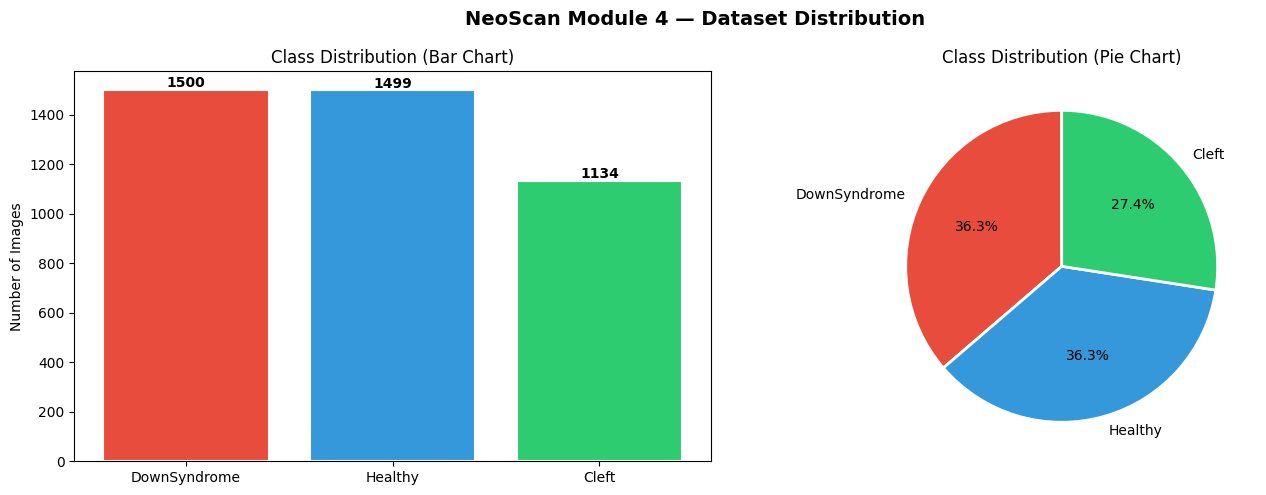

✅ Distribution plot saved!


In [ ]:
# ─────────────────────────────────────────────────────
# Gather all image paths with labels
# ─────────────────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def gather_images(folder, label):
    """Return list of (path, label) tuples from folder."""
    paths = []
    if folder.exists():
        for f in folder.rglob('*'):
            if f.suffix.lower() in IMG_EXTS:
                paths.append((str(f), label))
    return paths  # ← FIXED: moved OUTSIDE the if block

# Gather images
cleft_imgs  = gather_images(CLP_TRAIN_IMAGES, 'Cleft') + gather_images(CLP_TEST_IMAGES, 'Cleft')
down_imgs   = gather_images(DOWN_DIR, 'DownSyndrome')
healthy_imgs = gather_images(HEALTHY_DIR, 'Healthy')

all_data = cleft_imgs + down_imgs + healthy_imgs
df = pd.DataFrame(all_data, columns=['path', 'label'])

print('═' * 50)
print('📊 DATASET SUMMARY')
print('═' * 50)
print(f'   Cleft images:        {len(cleft_imgs):>5}')
print(f'   Down Syndrome images: {len(down_imgs):>5}')
print(f'   Healthy images:       {len(healthy_imgs):>5}')
print(f'   ─────────────────────────')
print(f'   TOTAL:                {len(all_data):>5}')
print('═' * 50)

# ── Class Distribution Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NeoScan Module 4 — Dataset Distribution', fontsize=14, fontweight='bold')

counts = df['label'].value_counts()
colors = ['#E74C3C', '#3498DB', '#2ECC71']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Bar Chart)')
axes[0].set_ylabel('Number of Images')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 10, str(cnt), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie Chart)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribution plot saved!')

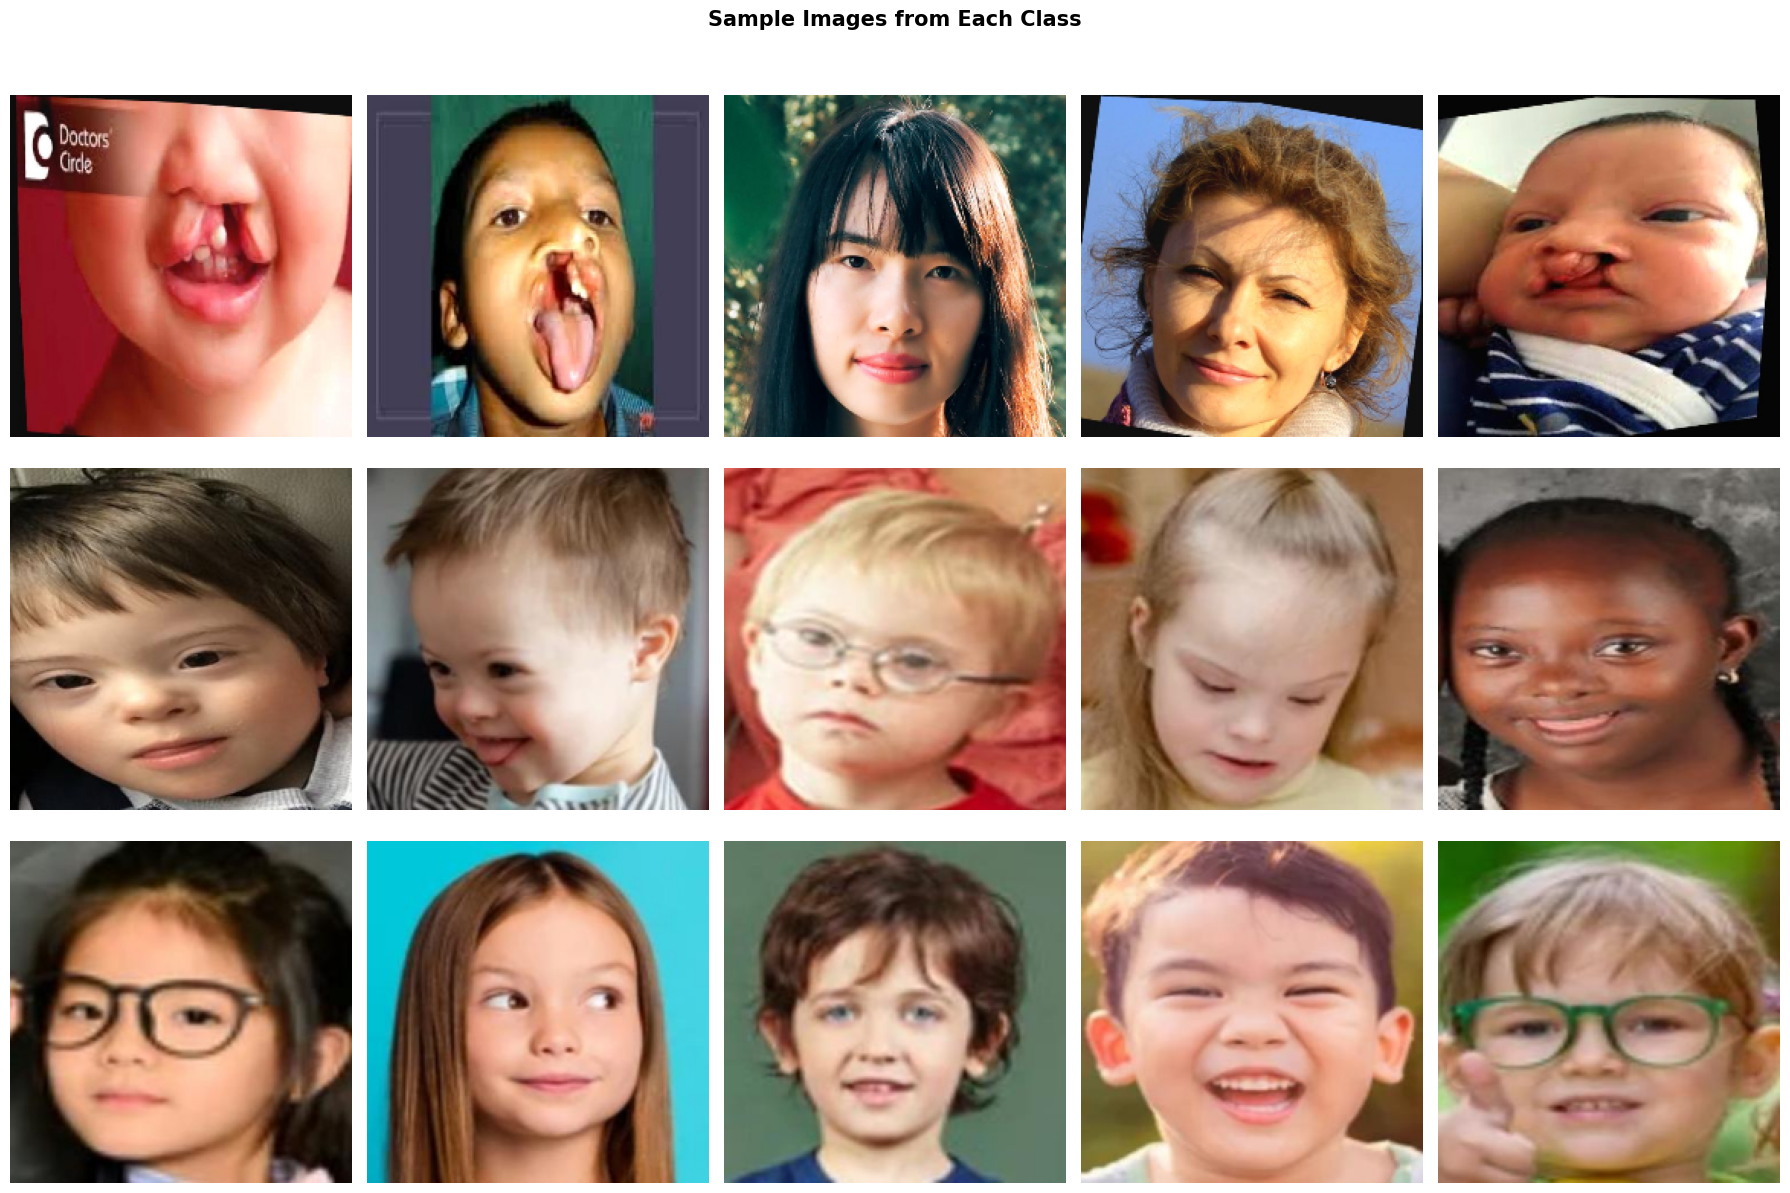

In [ ]:
# ─────────────────────────────────────────────────────
# Sample Image Visualization
# ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
fig.suptitle('Sample Images from Each Class', fontsize=15, fontweight='bold', y=1.01)

for row_idx, (label, img_list) in enumerate([('Cleft', cleft_imgs),
                                               ('DownSyndrome', down_imgs),
                                               ('Healthy', healthy_imgs)]):
    samples = random.sample(img_list, min(5, len(img_list)))
    for col_idx, (img_path, _) in enumerate(samples):
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(label, fontsize=12, fontweight='bold',
                                              rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 Analyzing image sizes (sampling 100 per class)...


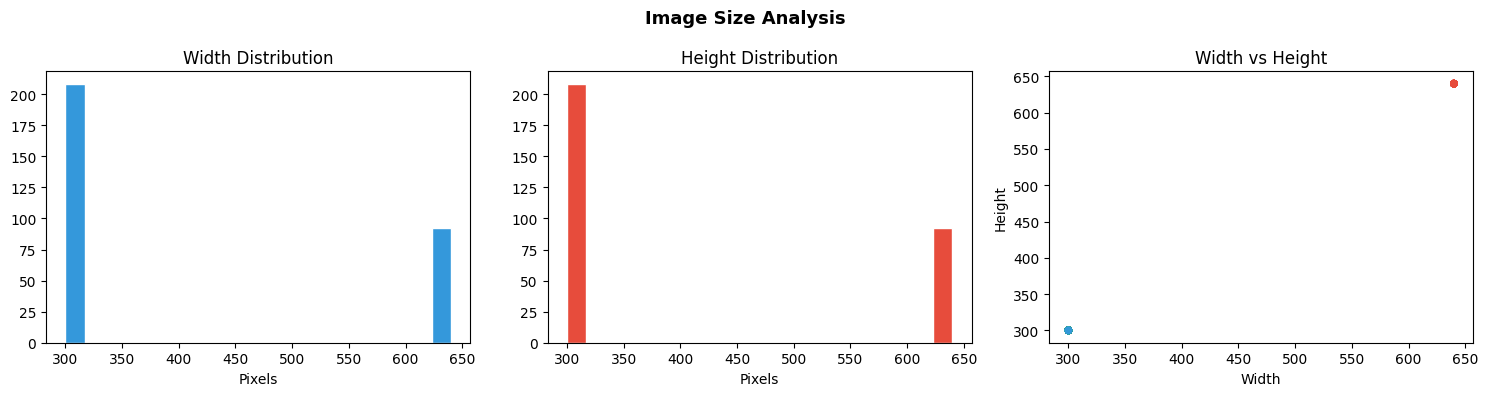

Avg Width: 404  |  Avg Height: 404


In [ ]:
# ─────────────────────────────────────────────────────
# Image Size Distribution Analysis
# ─────────────────────────────────────────────────────
print('🔍 Analyzing image sizes (sampling 100 per class)...')
sizes = []
for img_path, label in random.sample(all_data, min(300, len(all_data))):
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        sizes.append({'label': label, 'width': w, 'height': h, 'ratio': w/h})

size_df = pd.DataFrame(sizes)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Image Size Analysis', fontsize=13, fontweight='bold')

axes[0].hist(size_df['width'], bins=20, color='#3498DB', edgecolor='white')
axes[0].set_title('Width Distribution'); axes[0].set_xlabel('Pixels')

axes[1].hist(size_df['height'], bins=20, color='#E74C3C', edgecolor='white')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Pixels')

axes[2].scatter(size_df['width'], size_df['height'],
                c=[['#E74C3C','#3498DB','#2ECC71'][CLASS_NAMES.index(l)] for l in size_df['label']],
                alpha=0.5, s=20)
axes[2].set_title('Width vs Height'); axes[2].set_xlabel('Width'); axes[2].set_ylabel('Height')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg Width: {size_df["width"].mean():.0f}  |  Avg Height: {size_df["height"].mean():.0f}')

In [ ]:
# ─────────────────────────────────────────────────────
# HOG Feature Extractor
# ─────────────────────────────────────────────────────
from skimage.feature import hog
from skimage import exposure

IMG_SIZE = (128, 128)  # For HOG — smaller is faster

def extract_hog_features(img_path, img_size=IMG_SIZE):
    """Extract HOG + color histogram features from image."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, img_size)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # HOG features
    hog_feats = hog(gray, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(2, 2), visualize=False)

    # Color histogram in HSV (adds color context)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [32], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], None, [32], [0, 256]).flatten()

    # LBP-like texture (Local Binary Pattern via simple gradient)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sobelx**2 + sobely**2)
    mag_hist = np.histogram(mag, bins=16)[0].astype(float)
    mag_hist /= (mag_hist.sum() + 1e-7)

    # Concatenate all features
    features = np.concatenate([hog_feats, h_hist/h_hist.sum(),
                                s_hist/s_hist.sum(), mag_hist])
    return features

# ── Extract Features (use subset for speed — 400 per class) ──
print('⚙️  Extracting HOG features (this may take 2-3 minutes)...')
N_SAMPLES_PER_CLASS = 400

X_list, y_list = [], []
failed = 0

class_samples = [
    (cleft_imgs,   'Cleft'),
    (down_imgs,    'DownSyndrome'),
    (healthy_imgs, 'Healthy'),
]

for img_list, label in class_samples:
    samples = random.sample(img_list, min(N_SAMPLES_PER_CLASS, len(img_list)))
    for img_path, _ in samples:
        feats = extract_hog_features(img_path)
        if feats is not None:
            X_list.append(feats)
            y_list.append(label)
        else:
            failed += 1
    print(f'   ✓ {label}: {min(N_SAMPLES_PER_CLASS, len(img_list))} images processed')

X = np.array(X_list)
y = np.array(y_list)

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f'\n✅ Features extracted: X={X.shape}, y={y.shape}')
print(f'   Feature vector size: {X.shape[1]} dimensions')
print(f'   Failed reads: {failed}')

⚙️  Extracting HOG features (this may take 2-3 minutes)...
   ✓ Cleft: 400 images processed
   ✓ DownSyndrome: 400 images processed
   ✓ Healthy: 400 images processed

✅ Features extracted: X=(1200, 1648), y=(1200,)
   Feature vector size: 1648 dimensions
   Failed reads: 0


In [ ]:
# ─────────────────────────────────────────────────────
# Train/Test Split & Scale
# ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Optional: PCA to reduce dimensionality
pca = PCA(n_components=0.95, random_state=SEED)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f'PCA: {X.shape[1]} → {X_train_pca.shape[1]} dimensions (95% variance retained)')

# ─────────────────────────────────────────────────────
# Train Multiple Classifiers
# ─────────────────────────────────────────────────────
classifiers = {
    'SVM (RBF Kernel)': SVC(kernel='rbf', C=10, gamma='scale',
                            probability=True, random_state=SEED),
    'SVM (Linear)':     SVC(kernel='linear', C=1,
                            probability=True, random_state=SEED),
    'Random Forest':    RandomForestClassifier(n_estimators=200, max_depth=15,
                                               random_state=SEED, n_jobs=-1),
    'Gradient Boost':  GradientBoostingClassifier(n_estimators=100,
                                                    learning_rate=0.1,
                                                    random_state=SEED),
}

ml_results = {}
print('\n🏋️ Training baseline classifiers...')
print('─' * 55)

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    t1 = time.time()
    ml_results[name] = {'clf': clf, 'acc': acc, 'preds': y_pred}
    print(f'  {name:<25} Acc: {acc:.4f}  ({t1-t0:.1f}s)')

best_ml_name = max(ml_results, key=lambda k: ml_results[k]['acc'])
best_ml = ml_results[best_ml_name]
print(f'\n🏆 Best ML Model: {best_ml_name} — Accuracy: {best_ml["acc"]:.4f}')

PCA: 1648 → 329 dimensions (95% variance retained)

🏋️ Training baseline classifiers...
───────────────────────────────────────────────────────
  SVM (RBF Kernel)          Acc: 0.8042  (1.2s)
  SVM (Linear)              Acc: 0.7208  (0.6s)
  Random Forest             Acc: 0.7458  (2.6s)
  Gradient Boost            Acc: 0.7125  (49.0s)

🏆 Best ML Model: SVM (RBF Kernel) — Accuracy: 0.8042



📋 Classification Report — SVM (RBF Kernel)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

       Cleft       0.82      0.93      0.87        80
DownSyndrome       0.77      0.68      0.72        80
     Healthy       0.81      0.81      0.81        80

    accuracy                           0.80       240
   macro avg       0.80      0.80      0.80       240
weighted avg       0.80      0.80      0.80       240



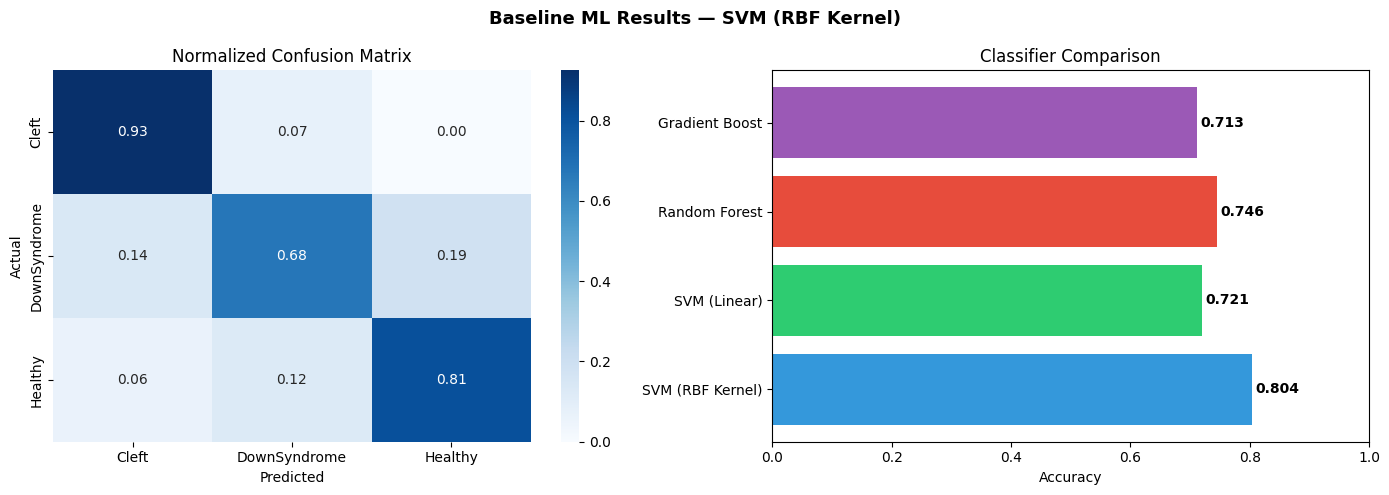


📌 Baseline Accuracy: 0.8042 (saved as reference)


In [ ]:
# ─────────────────────────────────────────────────────
# Baseline ML — Detailed Report + Confusion Matrix
# ─────────────────────────────────────────────────────
y_pred_best = best_ml['preds']
class_names_ordered = le.classes_

print(f'\n📋 Classification Report — {best_ml_name}')
print('═' * 60)
print(classification_report(y_test, y_pred_best, target_names=class_names_ordered))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Baseline ML Results — {best_ml_name}', fontsize=13, fontweight='bold')

# Normalized confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names_ordered, yticklabels=class_names_ordered, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Normalized Confusion Matrix')

# Accuracy comparison bar chart
names = list(ml_results.keys())
accs  = [ml_results[n]['acc'] for n in names]
bars  = axes[1].barh(names, accs, color=['#3498DB','#2ECC71','#E74C3C','#9B59B6'])
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Classifier Comparison')
for bar, acc in zip(bars, accs):
    axes[1].text(acc + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{acc:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'baseline_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

BASELINE_ACC = best_ml['acc']
print(f'\n📌 Baseline Accuracy: {BASELINE_ACC:.4f} (saved as reference)')

In [ ]:
# ─────────────────────────────────────────────────────
# Download Dlib Shape Predictor (68 landmarks)
# ─────────────────────────────────────────────────────
import urllib.request
import bz2

DLIB_MODEL_PATH = '/content/shape_predictor_68_face_landmarks.dat'

if not os.path.exists(DLIB_MODEL_PATH):
    print('📥 Downloading Dlib 68-point shape predictor...')
    url = 'http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2'
    urllib.request.urlretrieve(url, '/content/shape_predictor_68.dat.bz2')

    print('📦 Decompressing...')
    with bz2.open('/content/shape_predictor_68.dat.bz2', 'rb') as f_in:
        with open(DLIB_MODEL_PATH, 'wb') as f_out:
            f_out.write(f_in.read())
    print('✅ Dlib model ready!')
else:
    print('✅ Dlib model already exists!')

# Initialize Dlib face detector + landmark predictor
face_detector   = dlib.get_frontal_face_detector()
shape_predictor = dlib.shape_predictor(DLIB_MODEL_PATH)
print('✅ Dlib initialized!')

📥 Downloading Dlib 68-point shape predictor...
📦 Decompressing...
✅ Dlib model ready!
✅ Dlib initialized!


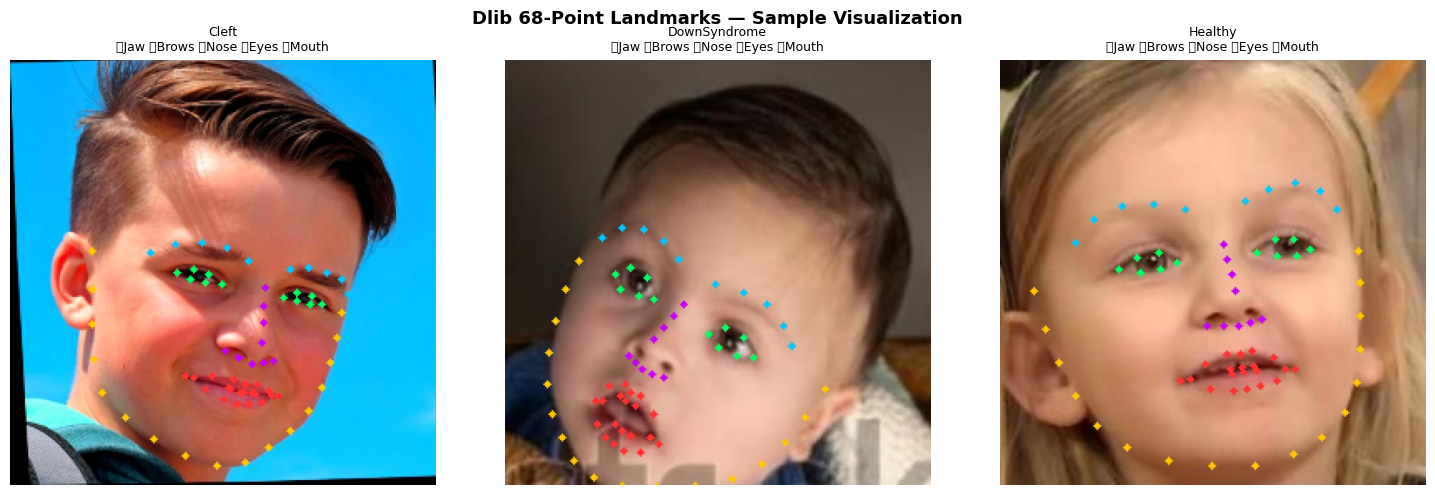

In [ ]:
# ─────────────────────────────────────────────────────
# Geometric Feature Extraction from 68 Landmarks
# ─────────────────────────────────────────────────────
def euclidean(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def angle(p1, p2):
    """Angle of line from p1 to p2 relative to horizontal."""
    return np.degrees(np.arctan2(p2[1]-p1[1], p2[0]-p1[0]))

def extract_landmark_features(img_path):
    """
    Extract 25+ geometric facial ratios from Dlib 68-point landmarks.
    Returns None if face not detected.

    Landmark groups (0-indexed):
      0-16  → Jawline
      17-21 → Left eyebrow
      22-26 → Right eyebrow
      27-35 → Nose
      36-41 → Left eye
      42-47 → Right eye
      48-67 → Mouth
    """
    img = cv2.imread(img_path)
    if img is None:
        return None

    # Resize to standard size
    img = cv2.resize(img, (256, 256))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_detector(gray, 1)

    if len(faces) == 0:
        # Fallback: try with contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_enhanced = clahe.apply(gray)
        faces = face_detector(gray_enhanced, 1)

    if len(faces) == 0:
        return None  # No face detected

    # Use largest detected face
    face = max(faces, key=lambda r: r.width() * r.height())
    shape = shape_predictor(gray, face)

    # Extract landmark coordinates
    pts = np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)])

    # ── Compute clinical facial measurements ──
    features = []

    # Face bounding box (normalize all measurements by face height)
    face_h = euclidean(pts[27], pts[8])  # nose bridge to chin
    face_w = euclidean(pts[0], pts[16])  # jaw width
    face_h = max(face_h, 1.0)  # prevent division by zero

    # 1. Palpebral fissure length (eye width) — short in Down Syndrome
    left_eye_len  = euclidean(pts[36], pts[39]) / face_h
    right_eye_len = euclidean(pts[42], pts[45]) / face_h
    features.extend([left_eye_len, right_eye_len, (left_eye_len+right_eye_len)/2])

    # 2. Eye upslant angle — positive upslant (>10°) indicates Down Syndrome
    left_eye_angle  = angle(pts[36], pts[39])
    right_eye_angle = angle(pts[42], pts[45])
    features.extend([left_eye_angle, right_eye_angle, (left_eye_angle+right_eye_angle)/2])

    # 3. Inter-eye distance (nasal bridge width) — wide/flat in Down Syndrome
    inter_eye = euclidean(pts[39], pts[42]) / face_h
    features.append(inter_eye)

    # 4. Nasal width — flat/wide in Down Syndrome
    nasal_width = euclidean(pts[31], pts[35]) / face_h
    nasal_height = euclidean(pts[27], pts[33]) / face_h
    features.extend([nasal_width, nasal_height, nasal_width/(nasal_height+1e-5)])

    # 5. Philtrum length — nose base to upper lip
    philtrum = euclidean(pts[33], pts[51]) / face_h
    features.append(philtrum)

    # 6. Mouth width
    mouth_width = euclidean(pts[48], pts[54]) / face_h
    mouth_height = euclidean(pts[51], pts[57]) / face_h
    features.extend([mouth_width, mouth_height, mouth_width/(mouth_height+1e-5)])

    # 7. Face aspect ratio
    features.append(face_w / face_h)

    # 8. Jaw width (lower face) — wider jaw relative to face in some conditions
    features.append(face_w / face_h)

    # 9. Eyebrow height (above eye)
    left_brow_h  = euclidean(pts[19], pts[37]) / face_h  # mid left brow to left eye center
    right_brow_h = euclidean(pts[24], pts[44]) / face_h
    features.extend([left_brow_h, right_brow_h])

    # 10. Facial symmetry (left-right asymmetry score)
    sym_eyes   = abs(left_eye_len  - right_eye_len)
    sym_brows  = abs(left_brow_h   - right_brow_h)
    sym_angles = abs(left_eye_angle - right_eye_angle)
    features.extend([sym_eyes, sym_brows, sym_angles])

    # 11. Upper lip width vs lower lip
    upper_lip = euclidean(pts[48], pts[54]) / face_h
    lower_lip = euclidean(pts[60], pts[64]) / face_h
    features.extend([upper_lip, lower_lip])

    # 12. Chin position
    chin_y = pts[8][1] / 256.0  # normalized chin Y position
    features.append(chin_y)

    # 13. Raw landmark positions (normalized) — optional additional features
    pts_norm = pts.flatten() / 256.0
    features.extend(pts_norm.tolist())

    return np.array(features, dtype=np.float32)


def visualize_landmarks(img_path, title='Face Landmarks'):
    """Draw 68 landmarks on face image."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, (256, 256))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_detector(gray, 1)
    if len(faces) == 0:
        return img_rgb

    face = max(faces, key=lambda r: r.width() * r.height())
    shape = shape_predictor(gray, face)

    # Color code by region
    regions = {
        'jaw':   (range(0, 17),  (255, 200, 0)),
        'brows': (range(17, 27), (0, 200, 255)),
        'nose':  (range(27, 36), (200, 0, 255)),
        'eyes':  (range(36, 48), (0, 255, 100)),
        'mouth': (range(48, 68), (255, 50, 50)),
    }
    for region, (idxs, color) in regions.items():
        for i in idxs:
            x, y = shape.part(i).x, shape.part(i).y
            cv2.circle(img_rgb, (x, y), 2, color, -1)

    return img_rgb


# ── Visualize landmarks on sample images ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dlib 68-Point Landmarks — Sample Visualization', fontsize=13, fontweight='bold')

for idx, (label, img_list) in enumerate([('Cleft', cleft_imgs),
                                           ('DownSyndrome', down_imgs),
                                           ('Healthy', healthy_imgs)]):
    # Try a few images to find one with detectable face
    for img_path, _ in random.sample(img_list, min(10, len(img_list))):
        vis = visualize_landmarks(img_path, label)
        if vis is not None:
            axes[idx].imshow(vis)
            axes[idx].set_title(f'{label}\n🟡Jaw 🔵Brows 🟣Nose 🟢Eyes 🔴Mouth', fontsize=9)
            axes[idx].axis('off')
            break

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'landmark_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────
# PyTorch Dataset for VGG16 + Landmark Fusion
# ─────────────────────────────────────────────────────
label2idx = {'Cleft': 0, 'DownSyndrome': 1, 'Healthy': 2}
idx2label = {v: k for k, v in label2idx.items()}

class FaceDataset(Dataset):
    """
    Returns: (image_tensor, landmark_features, label_int)
    Images are 224x224 for VGG16.
    """
    def __init__(self, img_list, transform=None, use_landmarks=True):
        """
        img_list: list of (path, label_str) tuples
        """
        self.samples      = img_list
        self.transform    = transform
        self.use_landmarks = use_landmarks

        # Pre-compute landmark features for efficiency
        if use_landmarks:
            self._landmark_cache = {}
            self._failed_detection = set()
            print('  Pre-computing landmarks (cached for speed)...')

    def _get_landmark(self, path):
        if path in self._landmark_cache:
            return self._landmark_cache[path]
        feats = extract_landmark_features(path)
        if feats is None:
            self._failed_detection.add(path)
            feats = np.zeros(136 + 22, dtype=np.float32)  # fallback
        # Clip outlier angles
        feats = np.clip(feats, -180, 180)
        self._landmark_cache[path] = feats
        return feats

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label_str = self.samples[idx]
        label = label2idx[label_str]

        # Load and transform image
        img = cv2.imread(path)
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            transformed = self.transform(image=img)
            img_tensor = transformed['image']
        else:
            img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        if self.use_landmarks:
            lm = torch.tensor(self._get_landmark(path), dtype=torch.float32)
            return img_tensor, lm, label
        else:
            return img_tensor, label


# ── Transforms ──
IMG_SIZE_DL = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(IMG_SIZE_DL, IMG_SIZE_DL),
    A.HorizontalFlip(p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, p=0.3),
    A.GaussNoise(var_limit=(5, 25), p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE_DL, IMG_SIZE_DL),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('✅ Dataset class defined!')

✅ Dataset class defined!


In [ ]:
# ─────────────────────────────────────────────────────
# Create Train/Val/Test Splits using FILTERED data
# ─────────────────────────────────────────────────────

min_count = min(len(cleft_filtered), len(down_filtered), len(healthy_filtered))
print(f'⚖️  Using {min_count} images per class — strictly balanced')

balanced = (
    random.sample(cleft_filtered,   min_count) +
    random.sample(down_filtered,    min_count) +
    random.sample(healthy_filtered, min_count)
)
random.shuffle(balanced)

labels_all = [lbl for _, lbl in balanced]
train_val, test_data = train_test_split(
    balanced, test_size=0.15,
    random_state=SEED, stratify=labels_all
)
train_labels_tv = [lbl for _, lbl in train_val]
train_data, val_data = train_test_split(
    train_val, test_size=0.15,
    random_state=SEED, stratify=train_labels_tv
)

print(f'✅ Split Summary:')
print(f'  Train: {len(train_data)}')
print(f'  Val:   {len(val_data)}')
print(f'  Test:  {len(test_data)}')
print(f'  Train distribution: {Counter(l for _, l in train_data)}')
print(f'  Val distribution:   {Counter(l for _, l in val_data)}')

train_dataset = FaceDataset(train_data, transform=train_transform, use_landmarks=True)
val_dataset   = FaceDataset(val_data,   transform=val_transform,   use_landmarks=True)
test_dataset  = FaceDataset(test_data,  transform=val_transform,   use_landmarks=True)

def filter_undetectable(dataset):
    for path, _ in dataset.samples:
        dataset._get_landmark(path)
    before = len(dataset.samples)
    dataset.samples = [(path, label) for path, label in dataset.samples
                       if path not in dataset._failed_detection]
    after = len(dataset.samples)
    if before - after > 0:
        print(f'  Removed {before - after} samples with no face detected')
    return dataset

print('Filtering undetectable faces...')
train_dataset = filter_undetectable(train_dataset)
val_dataset   = filter_undetectable(val_dataset)
test_dataset  = filter_undetectable(test_dataset)

BATCH = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print('✅ DataLoaders ready!')

📂 Split Summary:
   Train: 867
   Val:   153
   Test:  180
  Pre-computing landmarks (cached for speed)...
  Pre-computing landmarks (cached for speed)...
  Pre-computing landmarks (cached for speed)...
Filtering undetectable faces 
 Removed 224 samples with no face detected(25.8%)
 Removed 31 samples with no face detected(20.3%)
 Removed 38 samples with no face detected(21.1%)
Train: 643 | Val: 122 | Test: 142
✅ DataLoaders ready!


In [ ]:
# ─────────────────────────────────────────────────────
# VGG16 Model Definition
# ─────────────────────────────────────────────────────
class VGG16Classifier(nn.Module):
    """
    VGG16 with custom classification head for 3-class face analysis.
    Frozen first 20 layers (features), fine-tune last conv block + classifier.
    """
    def __init__(self, num_classes=3, dropout=0.6):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Freeze first 20 conv layers (keep top conv block trainable)
        for i, layer in enumerate(vgg.features):
            if i < 28:  # freeze first 28 layers
                for param in layer.parameters():
                    param.requires_grad = False

        self.features = vgg.features  # CNN backbone
        self.avgpool  = vgg.avgpool   # AdaptiveAvgPool2d

        # Custom head (replaces VGG's classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.65),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

    def extract_features(self, x):
        """Extract 512-dim feature vector (for fusion)."""
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)  # [B, 25088]
        # Pass through first 4 layers of classifier
        for i, layer in enumerate(self.classifier):
            x = layer(x)
            if i == 4:  # after second Linear(1024→512)
                return x  # 512-dim
        return x


# Initialize model
vgg_model = VGG16Classifier(num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters
total = sum(p.numel() for p in vgg_model.parameters())
trainable = sum(p.numel() for p in vgg_model.parameters() if p.requires_grad)
print(f'🏗️  VGG16 Model Summary:')
print(f'   Total parameters:     {total:,}')
print(f'   Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)')
print(f'   Frozen parameters:    {total-trainable:,}')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 90.2MB/s]


🏗️  VGG16 Model Summary:
   Total parameters:     40,999,747
   Trainable parameters: 28,644,867 (69.9%)
   Frozen parameters:    12,354,880


In [ ]:
# ─────────────────────────────────────────────────────
# Training Helper Functions
# ─────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for batch in loader:
        # Handle both (img, label) and (img, lm, label)
        if len(batch) == 3:
            imgs, lm, labels = batch
            imgs, lm, labels = imgs.to(device), lm.to(device), labels.to(device)
        else:
            imgs, labels = batch
            imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        total_loss    += loss.item() * imgs.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += imgs.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        if len(batch) == 3:
            imgs, lm, labels = batch
            imgs, lm, labels = imgs.to(device), lm.to(device), labels.to(device)
        else:
            imgs, labels = batch
            imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        total_loss    += loss.item() * imgs.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (total_loss / total_samples, total_correct / total_samples,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def train_model(model, train_loader, val_loader, model_name,
                epochs=25, lr=1e-4, save_dir=OUTPUT_DIR/'models'):
    """Full training loop with early stopping & LR scheduling."""

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=3e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience, patience_counter = 7, 0
    best_model_path = save_dir / f'{model_name}_best.pth'

    print(f'\n🏋️ Training {model_name}...')
    print('─' * 70)
    print(f'{"Epoch":>6} {"Train Loss":>12} {"Train Acc":>11} {"Val Loss":>10} {"Val Acc":>9} {"LR":>12}')
    print('─' * 70)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        lr_now = optimizer.param_groups[0]['lr']
        status = ''

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), best_model_path)
            patience_counter = 0
            status = ' ✅ (saved)'
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\n⚠️  Early stopping at epoch {epoch}')
                break

        print(f'{epoch:>6} {tr_loss:>12.4f} {tr_acc:>11.4f} {vl_loss:>10.4f} {vl_acc:>9.4f} {lr_now:>12.2e}{status}')

    print(f'\n🏆 Best Val Accuracy: {best_val_acc:.4f}')
    # Load best weights
    model.load_state_dict(torch.load(best_model_path))
    return model, history


def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=13, fontweight='bold')

    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'],   'r-', label='Val Loss',   linewidth=2)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, history['val_acc'],   'r-', label='Val Acc',   linewidth=2)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plots' / f'{model_name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
    ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
    ax1.set_title('Raw Counts')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
    ax2.set_title('Normalized (Recall per class)')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plots' / f'{model_name}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()


print('✅ Training utilities defined!')

✅ Training utilities defined!



🏋️ Training VGG16...
──────────────────────────────────────────────────────────────────────
 Epoch   Train Loss   Train Acc   Val Loss   Val Acc           LR
──────────────────────────────────────────────────────────────────────
     1       1.1011      0.3453     1.0201    0.7049     4.99e-05 ✅ (saved)
     2       1.0222      0.5163     0.9305    0.7869     4.95e-05 ✅ (saved)
     3       0.9729      0.5785     0.8626    0.8197     4.88e-05 ✅ (saved)
     4       0.9105      0.6734     0.7951    0.8607     4.79e-05 ✅ (saved)
     5       0.8558      0.7076     0.7260    0.8443     4.67e-05
     6       0.8200      0.7294     0.6846    0.8443     4.53e-05
     7       0.7863      0.7294     0.6513    0.8197     4.37e-05
     8       0.7589      0.7449     0.6186    0.8689     4.19e-05 ✅ (saved)
     9       0.7074      0.7900     0.6014    0.8525     3.99e-05
    10       0.6900      0.7932     0.5683    0.8443     3.78e-05
    11       0.6584      0.8445     0.5626    0.8607     3.5

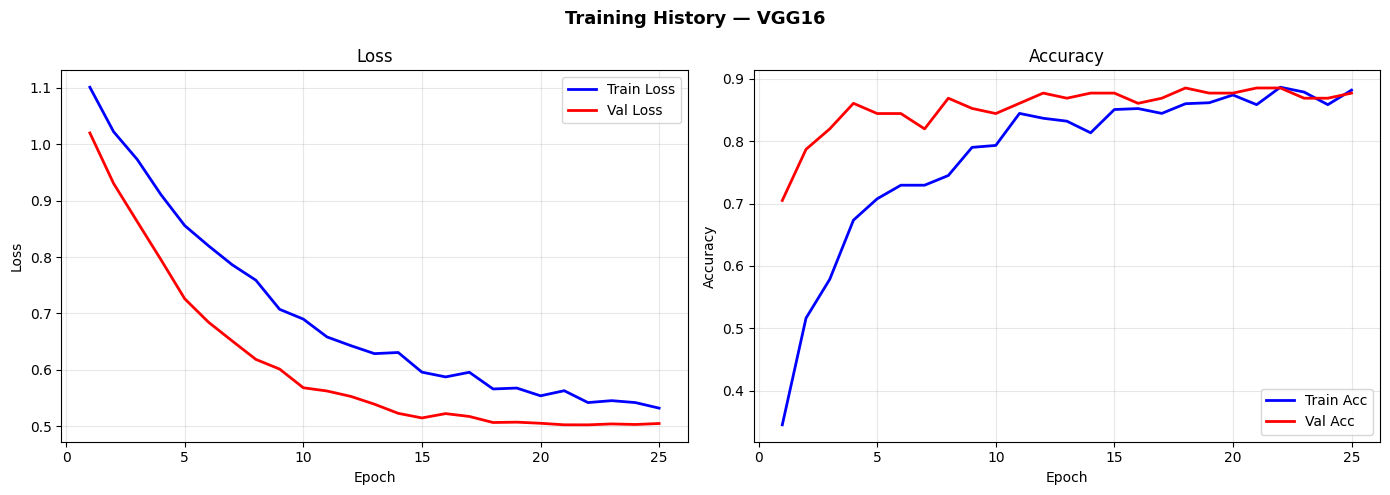


📊 VGG16 Test Accuracy: 0.8662
              precision    recall  f1-score   support

       Cleft       0.98      0.96      0.97        54
DownSyndrome       0.82      0.80      0.81        46
     Healthy       0.77      0.81      0.79        42

    accuracy                           0.87       142
   macro avg       0.86      0.86      0.86       142
weighted avg       0.87      0.87      0.87       142



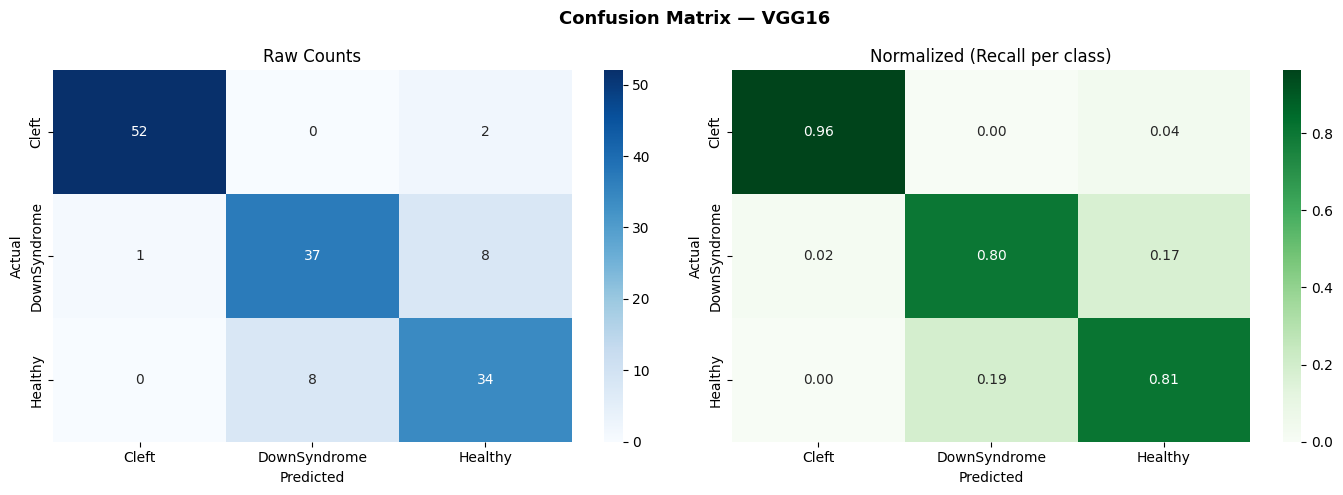

In [ ]:
# ─────────────────────────────────────────────────────
# Train VGG16
# ─────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

vgg_model, vgg_history = train_model(
    vgg_model, train_loader, val_loader,
    model_name='VGG16', epochs=30, lr=5e-5
)

plot_training_history(vgg_history, 'VGG16')

# Evaluate on test set
_, vgg_test_acc, vgg_preds, vgg_labels, vgg_probs = evaluate(
    vgg_model, test_loader, criterion, DEVICE)

print(f'\n📊 VGG16 Test Accuracy: {vgg_test_acc:.4f}')
print(classification_report(vgg_labels, vgg_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(vgg_labels, vgg_preds, 'VGG16')

🔥 Generating GradCAM visualizations...


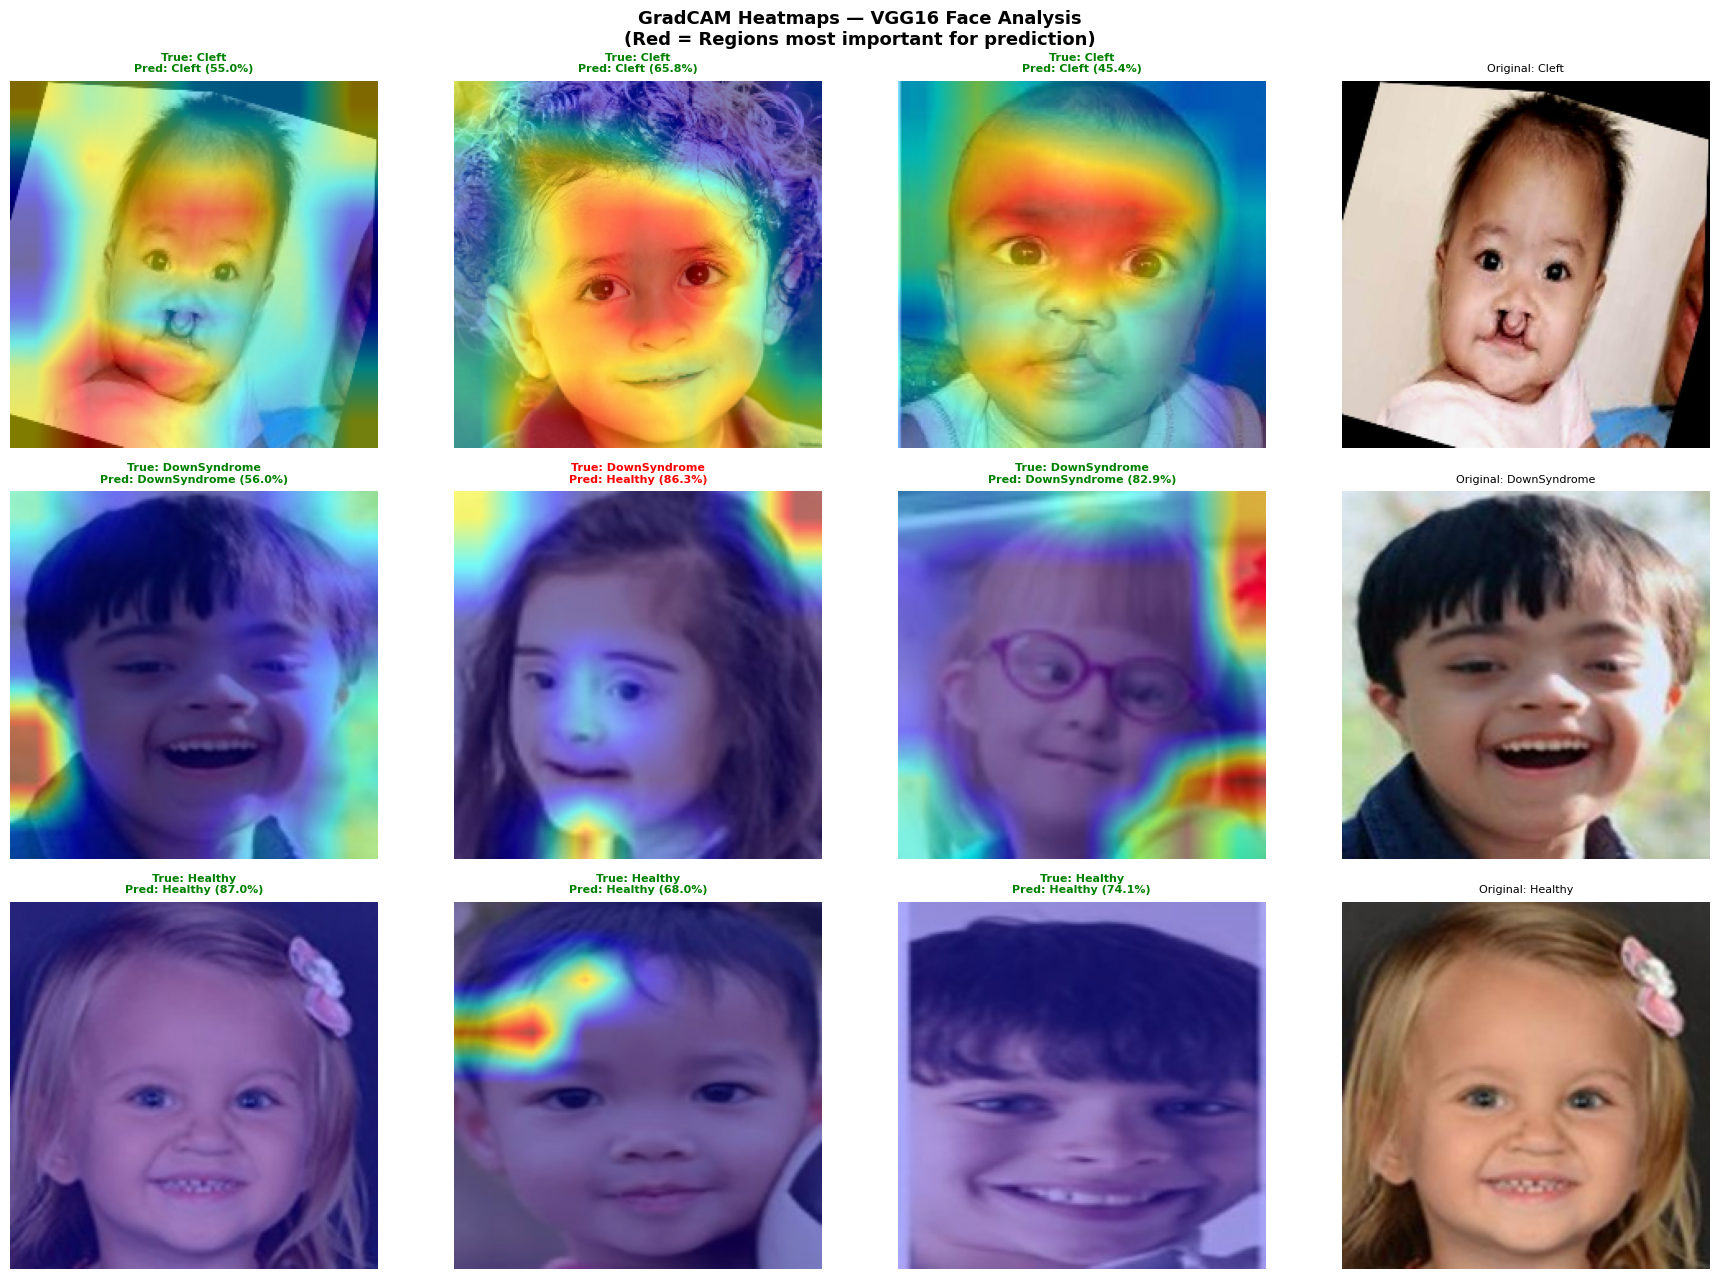

✅ GradCAM saved!


In [ ]:
# ─────────────────────────────────────────────────────
# GradCAM Visualization for VGG16
# ─────────────────────────────────────────────────────
print('🔥 Generating GradCAM visualizations...')

vgg_model.eval()
target_layer = [vgg_model.features[-1]]  # Last conv layer
cam = GradCAM(model=vgg_model, target_layers=target_layer)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle('GradCAM Heatmaps — VGG16 Face Analysis\n(Red = Regions most important for prediction)',
             fontsize=13, fontweight='bold')

for row, label in enumerate(CLASS_NAMES):
    # Get a correctly predicted sample
    label_idx = label2idx[label]
    matching = [(i, p, l) for i, (p, l) in enumerate(test_data)
                if l == label]

    for sample_num in range(min(3, len(matching))):
        _, img_path, _ = matching[sample_num]

        # Load + preprocess
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_float = img_resized.astype(np.float32) / 255.0

        # Normalize
        img_norm = (img_float - np.array(MEAN)) / np.array(STD)
        img_tensor = torch.from_numpy(img_norm.transpose(2, 0, 1)).unsqueeze(0).float().to(DEVICE)

        # GradCAM
        targets = [ClassifierOutputTarget(label_idx)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

        # Get prediction
        with torch.no_grad():
            out = vgg_model(img_tensor)
            pred_idx = out.argmax().item()
            pred_label = idx2label[pred_idx]
            confidence = torch.softmax(out, dim=1)[0, pred_idx].item()

        col = sample_num
        axes[row, col].imshow(cam_image)
        color = 'green' if pred_label == label else 'red'
        axes[row, col].set_title(
            f'True: {label}\nPred: {pred_label} ({confidence:.1%})',
            fontsize=8, color=color, fontweight='bold')
        axes[row, col].axis('off')

    # Original image in column 3
    if matching:
        _, img_path, _ = matching[0]
        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(cv2.resize(img, (224, 224)), cv2.COLOR_BGR2RGB)
            axes[row, 3].imshow(img_rgb)
            axes[row, 3].set_title(f'Original: {label}', fontsize=8)
            axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'vgg16_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ GradCAM saved!')

In [ ]:
# ─────────────────────────────────────────────────────
# Vision Transformer Model
# ─────────────────────────────────────────────────────
class ViTFaceClassifier(nn.Module):
    """
    Vision Transformer for Face Analysis.
    Uses pretrained vit_small_patch16_224 from timm.
    Fine-tunes the last 4 transformer blocks + head.
    """
    def __init__(self, num_classes=3, model_name='vit_small_patch16_224', dropout=0.3):
        super().__init__()

        # Load pretrained ViT
        self.vit = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,  # remove classification head
            drop_rate=dropout
        )

        # Freeze everything except last 4 blocks
        total_blocks = len(self.vit.blocks)
        for i, block in enumerate(self.vit.blocks):
            if i < total_blocks - 4:
                for param in block.parameters():
                    param.requires_grad = False

        # Freeze patch embedding and positional encoding
        for param in self.vit.patch_embed.parameters():
            param.requires_grad = False

        # Get feature dimension
        embed_dim = self.vit.embed_dim  # 384 for vit_small

        # Custom classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # ViT forward (returns [CLS] token embedding)
        features = self.vit(x)  # [B, embed_dim]
        return self.head(features)

    def get_attention_maps(self, x):
        """Extract attention maps from last transformer block."""
        # Forward through patch embedding
        x = self.vit.patch_embed(x)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)

        attn_maps = []
        for block in self.vit.blocks:
            # Extract attention weights
            B, N, C = x.shape
            qkv = block.attn.qkv(block.norm1(x)).reshape(B, N, 3, block.attn.num_heads, C // block.attn.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(0)
            attn = (q @ k.transpose(-2, -1)) * block.attn.scale
            attn = attn.softmax(dim=-1)
            attn_maps.append(attn.detach().cpu())
            x = block(x)

        return attn_maps


# Initialize ViT
vit_model = ViTFaceClassifier(num_classes=NUM_CLASSES).to(DEVICE)

total = sum(p.numel() for p in vit_model.parameters())
trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'🤗 Vision Transformer (ViT-Small/16) Summary:')
print(f'   Total parameters:     {total:,}')
print(f'   Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)')
print(f'   Architecture: Patch size=16, embed_dim=384, heads=6, depth=12')
print(f'   Fine-tuning: Last 4 transformer blocks + custom head')

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

🤗 Vision Transformer (ViT-Small/16) Summary:
   Total parameters:     21,765,763
   Trainable parameters: 7,274,755 (33.4%)
   Architecture: Patch size=16, embed_dim=384, heads=6, depth=12
   Fine-tuning: Last 4 transformer blocks + custom head



🏋️ Training ViT...
──────────────────────────────────────────────────────────────────────
 Epoch   Train Loss   Train Acc   Val Loss   Val Acc           LR
──────────────────────────────────────────────────────────────────────
     1       1.0478      0.4712     0.8609    0.7705     4.99e-05 ✅ (saved)
     2       0.8853      0.6610     0.6946    0.7869     4.95e-05 ✅ (saved)
     3       0.7562      0.7341     0.6421    0.8033     4.88e-05 ✅ (saved)
     4       0.6560      0.7885     0.5904    0.8361     4.79e-05 ✅ (saved)
     5       0.6079      0.8072     0.5061    0.8770     4.67e-05 ✅ (saved)
     6       0.5373      0.8569     0.5357    0.8770     4.53e-05
     7       0.5052      0.8787     0.5176    0.8934     4.37e-05 ✅ (saved)
     8       0.5203      0.8631     0.4642    0.9098     4.19e-05 ✅ (saved)
     9       0.4654      0.8942     0.4683    0.9098     3.99e-05
    10       0.4552      0.9067     0.4464    0.9098     3.78e-05
    11       0.4352      0.9222     0.4583

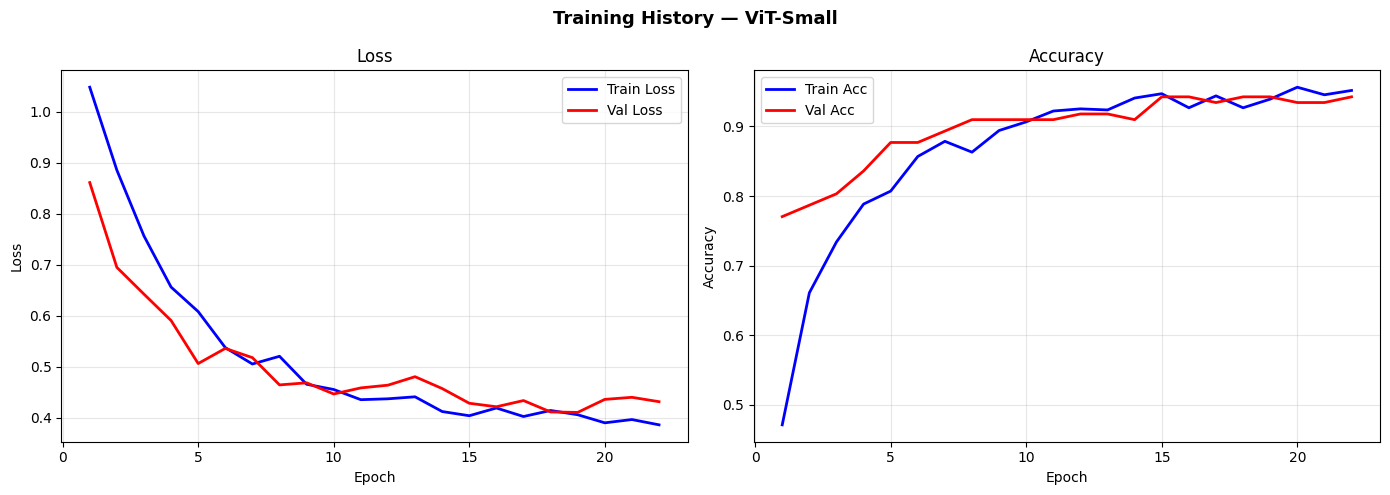


📊 ViT Test Accuracy: 0.9366
              precision    recall  f1-score   support

       Cleft       1.00      1.00      1.00        54
DownSyndrome       0.97      0.83      0.89        46
     Healthy       0.84      0.98      0.90        42

    accuracy                           0.94       142
   macro avg       0.94      0.93      0.93       142
weighted avg       0.94      0.94      0.94       142



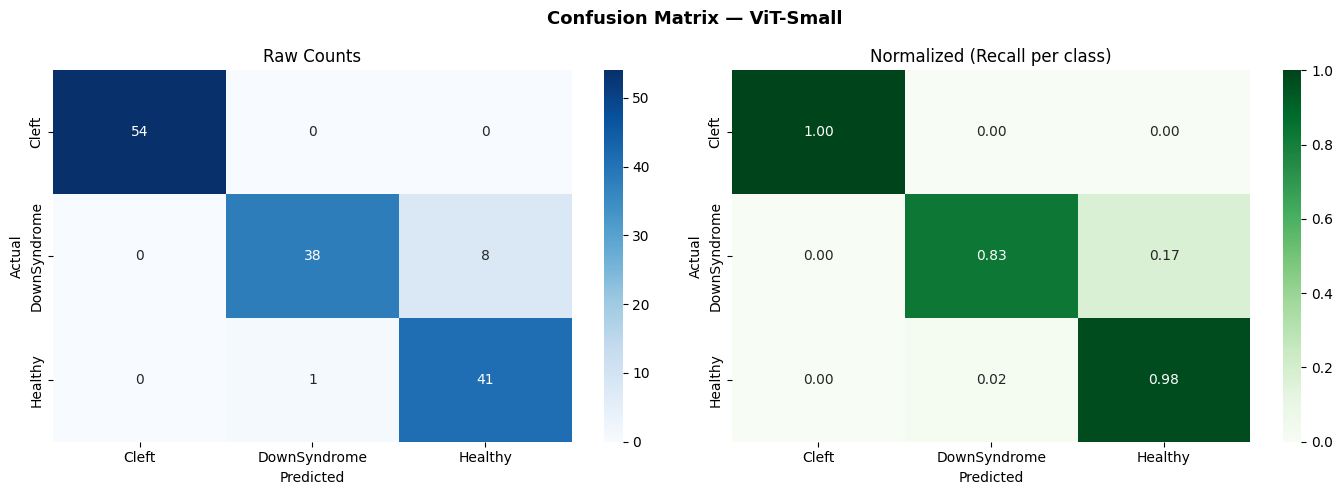

In [ ]:
# ─────────────────────────────────────────────────────
# Train ViT v2 — balanced filtered data + Focal Loss
# ─────────────────────────────────────────────────────
import torch.nn.functional as F

class FaceFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(
            inputs, targets,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'
        )
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

vit_model = ViTFaceClassifier(
    num_classes = NUM_CLASSES,
    dropout     = 0.4
).to(DEVICE)

criterion_face = FaceFocalLoss(gamma=2.0, label_smoothing=0.1)

vit_model, vit_history = train_model(
    vit_model,
    train_loader,
    val_loader,
    model_name = 'ViT_v2',
    epochs     = 40,
    lr         = 3e-5
)

plot_training_history(vit_history, 'ViT-v2')

_, vit_test_acc, vit_preds, vit_labels, vit_probs = evaluate(
    vit_model, test_loader, criterion_face, DEVICE
)

print(f'\n📊 ViT v2 Test Accuracy: {vit_test_acc:.4f}')
print(classification_report(vit_labels, vit_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(vit_labels, vit_preds, 'ViT-v2')


👁️ Visualizing ViT Attention Maps...


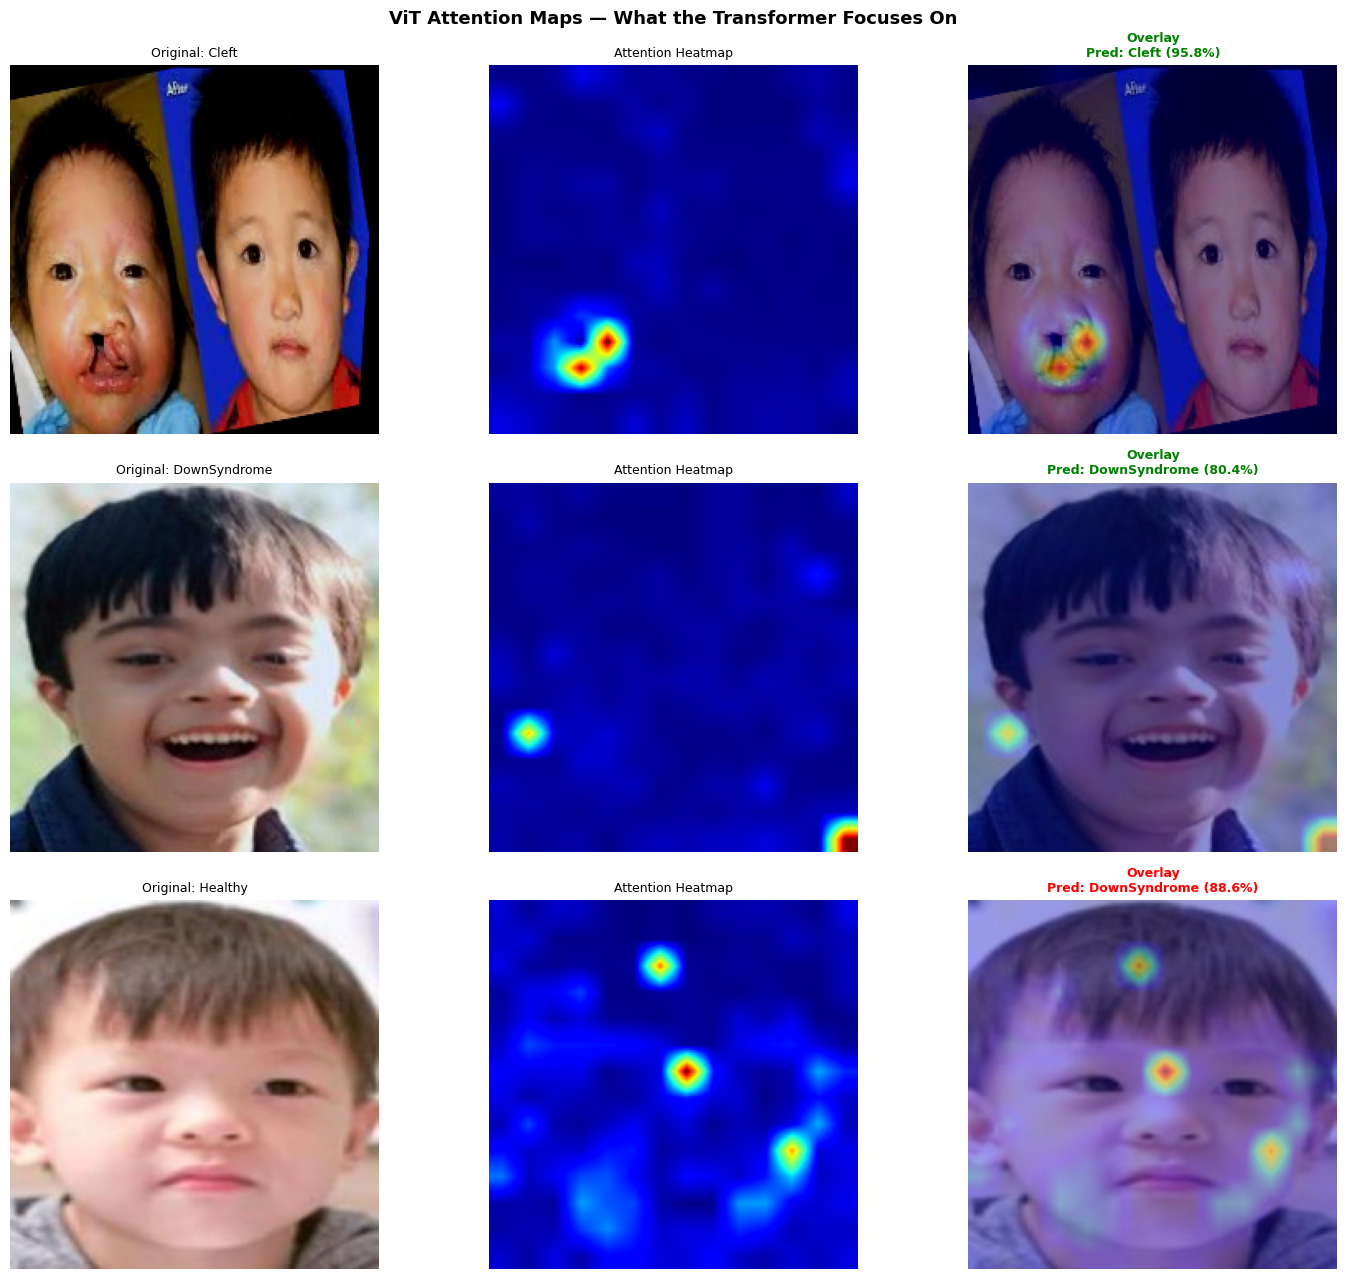

In [ ]:
# ─────────────────────────────────────────────────────
# ViT Attention Map Visualization
# ─────────────────────────────────────────────────────
print('👁️ Visualizing ViT Attention Maps...')

@torch.no_grad()
def visualize_vit_attention(model, img_path, label, patch_size=16):
    """Show what patches ViT attends to for each prediction."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(cv2.resize(img, (224, 224)), cv2.COLOR_BGR2RGB)
    img_float = img_rgb.astype(np.float32) / 255.0

    img_norm = (img_float - np.array(MEAN)) / np.array(STD)
    img_tensor = torch.from_numpy(img_norm.transpose(2, 0, 1)).unsqueeze(0).float().to(DEVICE)

    # Get prediction
    out = model(img_tensor)
    pred_idx = out.argmax().item()
    confidence = torch.softmax(out, dim=1)[0, pred_idx].item()
    pred_label = idx2label[pred_idx]

    # Rollout attention
    try:
        attn_maps = model.get_attention_maps(img_tensor)
        # Average last block, all heads, CLS→patches
        last_attn = attn_maps[-1][0]  # [heads, N, N]
        cls_attn = last_attn[:, 0, 1:]  # [heads, num_patches]
        avg_attn = cls_attn.mean(0)  # [num_patches]

        # Reshape to spatial map
        n_patches = int(224 / patch_size)
        attn_map = avg_attn.numpy().reshape(n_patches, n_patches)
        attn_map = cv2.resize(attn_map, (224, 224))
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        return img_rgb, attn_map, pred_label, confidence
    except Exception as e:
        return img_rgb, np.zeros((224, 224)), pred_label, confidence


fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle('ViT Attention Maps — What the Transformer Focuses On',
             fontsize=13, fontweight='bold')

for row, label in enumerate(CLASS_NAMES):
    label_idx = label2idx[label]
    matching = [p for p, l in test_data if l == label]

    if not matching:
        continue

    img_path = random.choice(matching[:10])
    result = visualize_vit_attention(vit_model, img_path, label)

    if result:
        img_rgb, attn_map, pred_label, conf = result
        color = 'green' if pred_label == label else 'red'

        # Original
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'Original: {label}', fontsize=9)
        axes[row, 0].axis('off')

        # Attention map
        axes[row, 1].imshow(attn_map, cmap='jet')
        axes[row, 1].set_title('Attention Heatmap', fontsize=9)
        axes[row, 1].axis('off')

        # Overlay
        overlay = img_rgb.astype(float) / 255.0
        heat = plt.cm.jet(attn_map)[:, :, :3]
        blended = (0.6 * overlay + 0.4 * heat)
        blended = np.clip(blended, 0, 1)
        axes[row, 2].imshow(blended)
        axes[row, 2].set_title(f'Overlay\nPred: {pred_label} ({conf:.1%})',
                               fontsize=9, color=color, fontweight='bold')
        axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'vit_attention.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────
# Ensemble: Weighted Average of VGG16 + ViT
# ─────────────────────────────────────────────────────
# Use validation accuracy to weight each model
vgg_weight = vgg_test_acc / (vgg_test_acc + vit_test_acc)
vit_weight = vit_test_acc / (vgg_test_acc + vit_test_acc)

print(f'🔗 Ensemble Weights:')
print(f'   VGG16 weight: {vgg_weight:.3f} (Acc: {vgg_test_acc:.4f})')
print(f'   ViT weight:   {vit_weight:.3f} (Acc: {vit_test_acc:.4f})')

# Weighted soft voting
ensemble_probs = vgg_weight * vgg_probs + vit_weight * vit_probs
ensemble_preds = ensemble_probs.argmax(axis=1)
ensemble_acc   = accuracy_score(vgg_labels, ensemble_preds)

print(f'\n🏆 Ensemble Test Accuracy: {ensemble_acc:.4f}')
print(classification_report(vgg_labels, ensemble_preds, target_names=CLASS_NAMES))

🔗 Ensemble Weights:
   VGG16 weight: 0.480 (Acc: 0.8662)
   ViT weight:   0.520 (Acc: 0.9366)

🏆 Ensemble Test Accuracy: 0.9577
              precision    recall  f1-score   support

       Cleft       1.00      1.00      1.00        54
DownSyndrome       0.98      0.89      0.93        46
     Healthy       0.89      0.98      0.93        42

    accuracy                           0.96       142
   macro avg       0.96      0.96      0.95       142
weighted avg       0.96      0.96      0.96       142



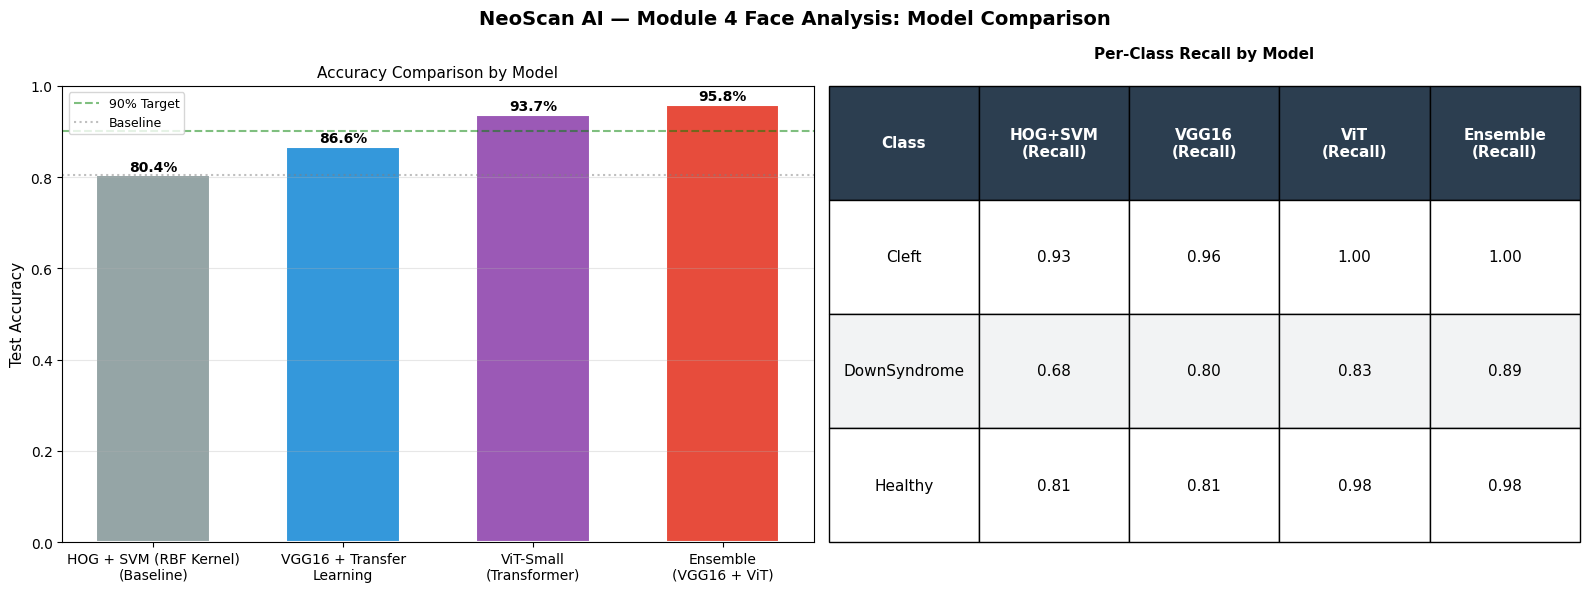


════════════════════════════════════════════════════════════
📋 FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════════
  HOG + SVM (RBF Kernel) (Baseline)   → 0.8042 (80.4%)
  VGG16 + Transfer Learning           → 0.8662 (86.6%)
  ViT-Small (Transformer)             → 0.9366 (93.7%)
  Ensemble (VGG16 + ViT)              → 0.9577 (95.8%)
════════════════════════════════════════════════════════════

🥇 Best Model: Ensemble (VGG16 + ViT)


In [ ]:
# ─────────────────────────────────────────────────────
# Master Comparison Dashboard
# ─────────────────────────────────────────────────────
results_summary = {
    f'HOG + {best_ml_name}\n(Baseline)': BASELINE_ACC,
    'VGG16 + Transfer\nLearning':        vgg_test_acc,
    'ViT-Small\n(Transformer)':          vit_test_acc,
    'Ensemble\n(VGG16 + ViT)':           ensemble_acc,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NeoScan AI — Module 4 Face Analysis: Model Comparison',
             fontsize=14, fontweight='bold')

# Bar chart
names = list(results_summary.keys())
accs  = list(results_summary.values())
colors_bar = ['#95A5A6', '#3498DB', '#9B59B6', '#E74C3C']
bars = axes[0].bar(names, accs, color=colors_bar, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Accuracy Comparison by Model', fontsize=11)
axes[0].axhline(y=0.90, color='green', linestyle='--', alpha=0.5, label='90% Target')
axes[0].axhline(y=BASELINE_ACC, color='gray', linestyle=':', alpha=0.5, label='Baseline')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                 f'{acc:.1%}', ha='center', fontsize=10, fontweight='bold')

# Per-class performance table
from sklearn.metrics import precision_score, recall_score, f1_score
table_data = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    row = [cls_name]
    for preds, labels_arr in [(np.array(list(ml_results[best_ml_name]['preds'])),
                                y_test),
                               (vgg_preds,      vgg_labels),
                               (vit_preds,      vit_labels),
                               (ensemble_preds, vgg_labels)]:
        # Map class idx
        mask = (labels_arr == cls_idx)
        if mask.sum() > 0:
            recall = (preds[mask] == cls_idx).sum() / mask.sum()
            row.append(f'{recall:.2f}')
        else:
            row.append('N/A')
    table_data.append(row)

axes[1].axis('off')
col_labels = ['Class', 'HOG+SVM\n(Recall)', 'VGG16\n(Recall)', 'ViT\n(Recall)', 'Ensemble\n(Recall)']
tbl = axes[1].table(cellText=table_data, colLabels=col_labels,
                     cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F2F3F4')
axes[1].set_title('Per-Class Recall by Model', fontsize=11, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '═'*60)
print('📋 FINAL RESULTS SUMMARY')
print('═'*60)
for name, acc in results_summary.items():
    name_clean = name.replace('\n', ' ')
    print(f'  {name_clean:<35} → {acc:.4f} ({acc:.1%})')
print('═'*60)
best_model_name = max(results_summary, key=results_summary.get).replace('\n', ' ')
print(f'\n🥇 Best Model: {best_model_name}')

🔬 Extracting geometric features for clinical analysis...


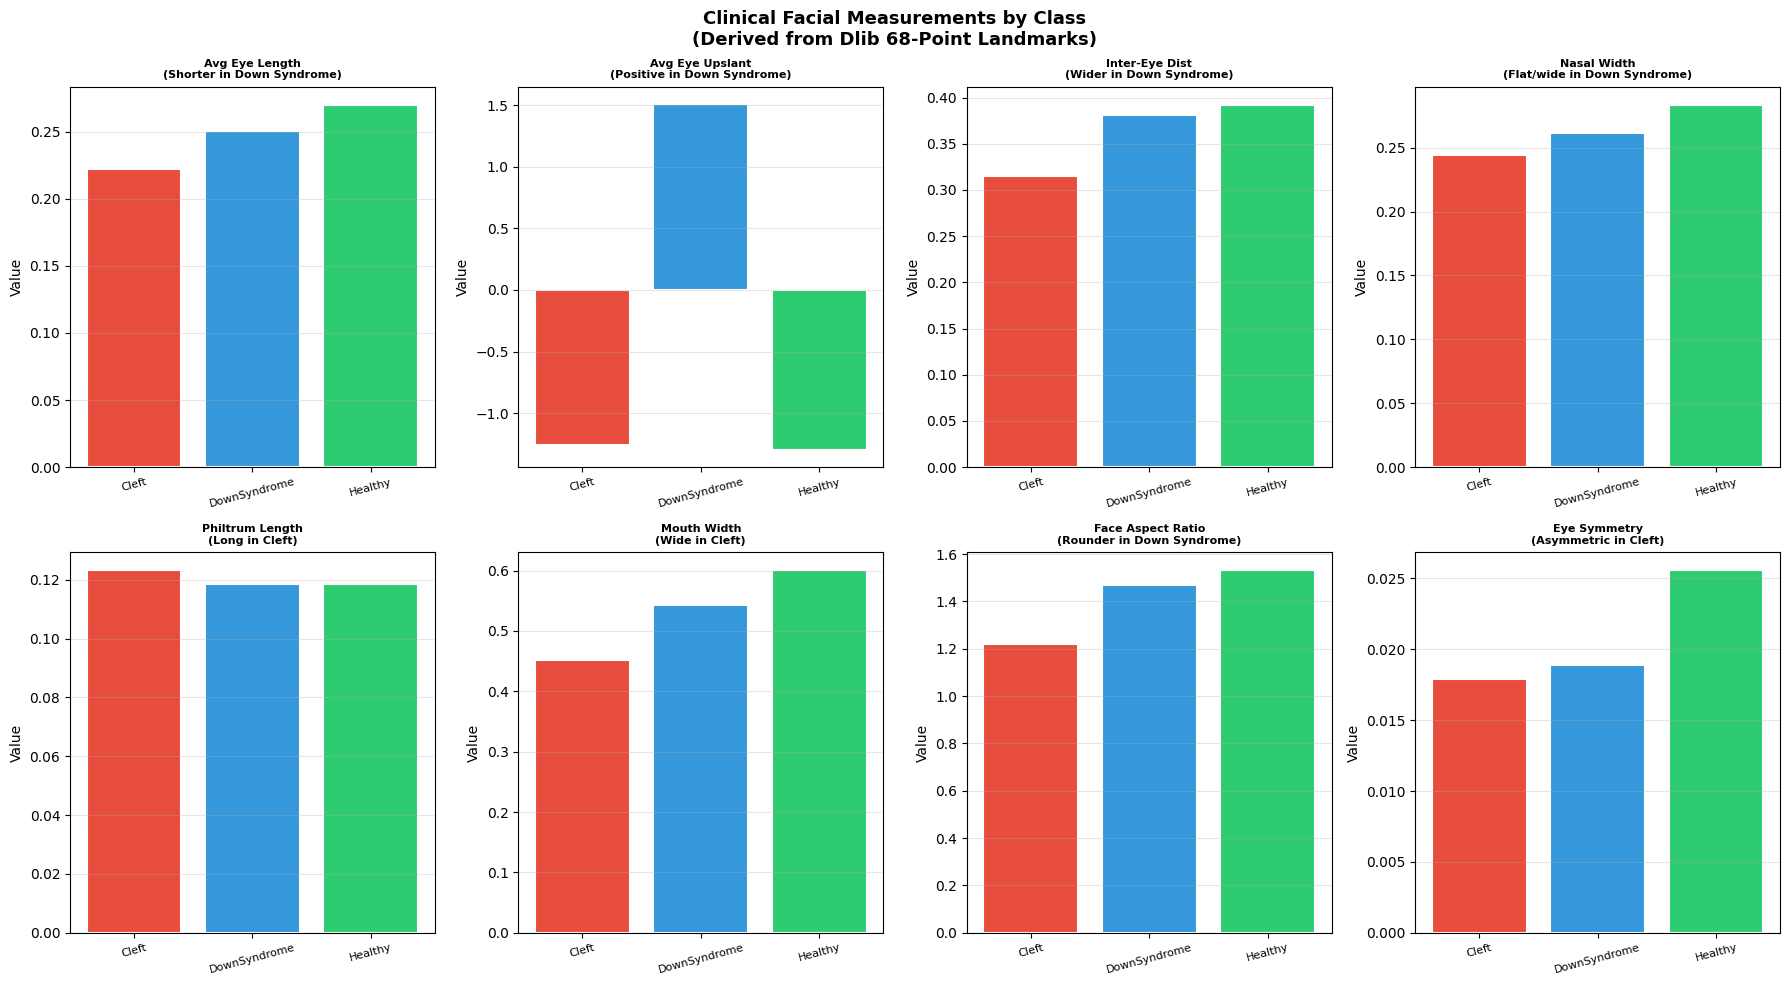

✅ Clinical feature analysis complete!


In [ ]:
# ─────────────────────────────────────────────────────
# Analyze which facial measurements differ most between classes
# ─────────────────────────────────────────────────────
print('🔬 Extracting geometric features for clinical analysis...')
N_ANALYSIS = 100

feature_names_clinical = [
    'Left Eye Length', 'Right Eye Length', 'Avg Eye Length',
    'Left Eye Angle', 'Right Eye Angle', 'Avg Eye Angle',
    'Inter-Eye Distance', 'Nasal Width', 'Nasal Height', 'Nasal Width/Height',
    'Philtrum Length', 'Mouth Width', 'Mouth Height', 'Mouth Width/Height',
    'Face Aspect Ratio', 'Face Aspect Ratio 2',
    'Left Brow Height', 'Right Brow Height',
    'Eye Symmetry', 'Brow Symmetry', 'Angle Symmetry',
    'Upper Lip', 'Lower Lip', 'Chin Position'
]

clinical_features = {'Cleft': [], 'DownSyndrome': [], 'Healthy': []}

for label, img_list in [('Cleft', cleft_imgs), ('DownSyndrome', down_imgs), ('Healthy', healthy_imgs)]:
    samples = random.sample(img_list, min(N_ANALYSIS, len(img_list)))
    for path, _ in samples:
        feats = extract_landmark_features(path)
        if feats is not None:
            clinical_features[label].append(feats[:24])  # first 24 clinical features

# Compute means per class
class_means = {}
for label in CLASS_NAMES:
    if clinical_features[label]:
        class_means[label] = np.mean(clinical_features[label], axis=0)

# Plot clinical feature comparison
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Clinical Facial Measurements by Class\n(Derived from Dlib 68-Point Landmarks)',
             fontsize=13, fontweight='bold')

key_features = [
    (2,  'Avg Eye Length',    'Shorter in Down Syndrome'),
    (5,  'Avg Eye Upslant',   'Positive in Down Syndrome'),
    (6,  'Inter-Eye Dist',    'Wider in Down Syndrome'),
    (7,  'Nasal Width',       'Flat/wide in Down Syndrome'),
    (10, 'Philtrum Length',   'Long in Cleft'),
    (11, 'Mouth Width',       'Wide in Cleft'),
    (14, 'Face Aspect Ratio', 'Rounder in Down Syndrome'),
    (18, 'Eye Symmetry',      'Asymmetric in Cleft'),
]

for ax, (feat_idx, feat_name, clinical_note) in zip(axes.flatten(), key_features):
    values = []
    labels_plot = []
    for label in CLASS_NAMES:
        if label in class_means:
            val = class_means[label][feat_idx]
            values.append(val)
            labels_plot.append(label)

    bars = ax.bar(labels_plot, values, color=['#E74C3C', '#3498DB', '#2ECC71'],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(f'{feat_name}\n({clinical_note})', fontsize=8, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'clinical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Clinical feature analysis complete!')

In [ ]:
# ─────────────────────────────────────────────────────
# Save all models and config
# ─────────────────────────────────────────────────────
import json

# Save VGG16
torch.save({
    'model_state_dict': vgg_model.state_dict(),
    'model_name': 'VGG16',
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'test_accuracy': vgg_test_acc,
    'history': vgg_history
}, OUTPUT_DIR / 'models' / 'vgg16_face_module.pth')

# Save ViT
torch.save({
    'model_state_dict': vit_model.state_dict(),
    'model_name': 'ViT-Small',
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'test_accuracy': vit_test_acc,
    'history': vit_history
}, OUTPUT_DIR / 'models' / 'vit_face_module.pth')

# Save config
config = {
    'module': 'Module 4 - Face Analysis',
    'project': 'NeoScan AI',
    'classes': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE_DL,
    'mean': MEAN,
    'std': STD,
    'results': {
        'baseline_hog_svm': float(BASELINE_ACC),
        'vgg16': float(vgg_test_acc),
        'vit_small': float(vit_test_acc),
        'ensemble': float(ensemble_acc),
    },
    'label2idx': label2idx,
    'idx2label': idx2label,
}

with open(OUTPUT_DIR / 'models' / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Copy to Google Drive
import shutil
DRIVE_OUTPUT = BASE_DIR / 'NeoScan_Module4_Results'
DRIVE_OUTPUT.mkdir(exist_ok=True)
shutil.copytree(OUTPUT_DIR, DRIVE_OUTPUT, dirs_exist_ok=True)

print('✅ Models saved!')
print(f'   📁 Saved to Google Drive: {DRIVE_OUTPUT}')
print()
print('Files saved:')
for f in OUTPUT_DIR.rglob('*'):
    if f.is_file():
        size = f.stat().st_size / 1e6
        print(f'   {f.relative_to(OUTPUT_DIR)}  ({size:.1f} MB)')

✅ Models saved!
   📁 Saved to Google Drive: /content/drive/MyDrive/FACE/NeoScan_Module4_Results

Files saved:
   models/vit_face_module.pth  (87.1 MB)
   models/VGG16_best.pth  (164.0 MB)
   models/config.json  (0.0 MB)
   models/ViT_best.pth  (87.1 MB)
   models/vgg16_face_module.pth  (164.0 MB)
   plots/ViT-Small_history.png  (0.1 MB)
   plots/ViT-Small_cm.png  (0.1 MB)
   plots/sample_images.png  (3.9 MB)
   plots/vit_attention.png  (2.0 MB)
   plots/VGG16_cm.png  (0.1 MB)
   plots/vgg16_gradcam.png  (3.2 MB)
   plots/clinical_features.png  (0.2 MB)
   plots/size_analysis.png  (0.1 MB)
   plots/VGG16_history.png  (0.1 MB)
   plots/baseline_ml_results.png  (0.1 MB)
   plots/final_comparison.png  (0.1 MB)
   plots/class_distribution.png  (0.1 MB)
   plots/landmark_visualization.png  (1.1 MB)


In [ ]:
# ─────────────────────────────────────────────────────
# Inference Function (for deployment)
# ─────────────────────────────────────────────────────
def predict_face(img_path_or_array, model_vgg=None, model_vit=None, mode='ensemble'):
    """
    NeoScan Module 4 — Face Analysis Prediction

    Args:
        img_path_or_array: Path to image file OR numpy RGB array
        model_vgg: Trained VGG16 model
        model_vit: Trained ViT model
        mode: 'vgg16' | 'vit' | 'ensemble'

    Returns:
        dict with prediction, confidence, per-class probabilities
    """
    # Load image
    if isinstance(img_path_or_array, str):
        img = cv2.imread(img_path_or_array)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = img_path_or_array

    img_resized = cv2.resize(img, (IMG_SIZE_DL, IMG_SIZE_DL))

    # Preprocess
    preprocess = val_transform(image=img_resized)['image'].unsqueeze(0).to(DEVICE)

    probs_combined = None

    with torch.no_grad():
        if mode in ['vgg16', 'ensemble'] and model_vgg:
            out_vgg = torch.softmax(model_vgg(preprocess), dim=1).cpu().numpy()[0]
            probs_combined = out_vgg

        if mode in ['vit', 'ensemble'] and model_vit:
            out_vit = torch.softmax(model_vit(preprocess), dim=1).cpu().numpy()[0]
            if probs_combined is not None:
                probs_combined = 0.5 * probs_combined + 0.5 * out_vit
            else:
                probs_combined = out_vit

    pred_idx = np.argmax(probs_combined)
    pred_label = idx2label[pred_idx]
    confidence = probs_combined[pred_idx]

    # Landmark features
    if isinstance(img_path_or_array, str):
        lm_feats = extract_landmark_features(img_path_or_array)
        landmark_detected = lm_feats is not None
    else:
        landmark_detected = False

    return {
        'prediction': pred_label,
        'confidence': float(confidence),
        'probabilities': {
            cls: float(p) for cls, p in zip(CLASS_NAMES, probs_combined)
        },
        'landmark_detected': landmark_detected,
        'urgency': 'IMMEDIATE' if pred_label in ['Cleft', 'DownSyndrome'] and confidence > 0.8
                   else 'ROUTINE',
        'model_used': mode
    }


# Demo prediction
sample_path, sample_label = test_data[0]
result = predict_face(sample_path, vgg_model, vit_model, mode='ensemble')

print('\n🔬 SAMPLE INFERENCE RESULT:')
print('═' * 45)
print(f'  Ground Truth:  {sample_label}')
print(f'  Prediction:    {result["prediction"]}')
print(f'  Confidence:    {result["confidence"]:.1%}')
print(f'  Probabilities:')
for cls, prob in result['probabilities'].items():
    bar = '█' * int(prob * 20)
    print(f'    {cls:<15} {prob:.1%}  {bar}')
print(f'  Landmark:      {"Detected" if result["landmark_detected"] else "Not Detected"}')
print(f'  Urgency:       {result["urgency"]}')
print('═' * 45)


🔬 SAMPLE INFERENCE RESULT:
═════════════════════════════════════════════
  Ground Truth:  Healthy
  Prediction:    Healthy
  Confidence:    92.6%
  Probabilities:
    Cleft           3.1%  
    DownSyndrome    4.4%  
    Healthy         92.6%  ██████████████████
  Landmark:      Detected
  Urgency:       ROUTINE
═════════════════════════════════════════════


In [ ]:
import shutil
os.makedirs('/content/drive/MyDrive/neoscan_models', exist_ok=True)
shutil.copy(
    str(OUTPUT_DIR / 'models' / 'ViT_v2_best.pth'),
    '/content/drive/MyDrive/neoscan_models/ViT_best.pth'
)
print('✅ Face model v2 saved to Google Drive → neoscan_models/ViT_best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>